In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.optimize import fsolve
%run IPR.ipynb
%run VLP.ipynb

In [21]:
# Effect of skin (increasing or decreasing drawdown)
def skin(delta_P_skin_red):
    F_new = (Pr - Pwf_IPR - (delta_P_skin-delta_P_skin_red) )/(Pr - Pwf_IPR)
    Pwf_array_IPR_new, Qo_array_new = Vogel_IPR(Qo_IPR, Pwf_IPR + delta_P_skin_red, Pr, Pb)
    Pwf_predictator_IPR_new = splrep(Qo_array_new, Pwf_array_IPR_new, k=3, s=9)
    Pwf_predicted_IPR_new = splev(Qo_array_new, Pwf_predictator_IPR_new)

    Qo_array_VLP1 = Qo_array_new[1:] if Qo_array_new[len(Qo_array_new) - 1] >= Qo_array_IPR[len(Qo_array_IPR)-1] else Qo_array_IPR[1:]
    Pwf_array_VLP1 = Poettmann_and_Carpenter_Method(Pwh_VLP, T, d, API, GLR, Bw, fo, fw, Yg, Yo, Yw, Qo_array_VLP, depth)
    Pwf_predictator_VLP1 = splrep(Qo_array_VLP, Pwf_array_VLP, k=3, s=9)
    Pwf_predicted_VLP1 = splev(Qo_array_VLP, Pwf_predictator_VLP )

    print(f"New Operating Condition: ( Qo (STB/day), Pwf (psi) ) = ({calculate_intersection(Pwf_predictator_VLP1, Pwf_predictator_IPR_new, initial_guess=500.0)[0]:.2f}, {calculate_intersection(Pwf_predictator_VLP1, Pwf_predictator_IPR_new, initial_guess=500.0)[1]:.2f})")

    # Create the plot
    plt.plot( Qo_array_VLP1, Pwf_predicted_VLP1, 'o', label='VLP', color='orange')
    plt.plot(Qo_array_VLP1, Pwf_predicted_VLP1, '-', color='orange')
    plt.plot( Qo_array_IPR, Pwf_array_IPR, 'o', label=f'IPR (Actual i.e. F={F})', color='blue')
    plt.plot(Qo_array_IPR, Pwf_predicted_IPR, '-', color='blue')
    #plt.plot( Qo_array_new , Pwf_array_IPR_new, 'o', label=f'IPR (New i.e. F={F_new})', color='blue')
    plt.plot(Qo_array_new ,  Pwf_predicted_IPR_new, '--', label=f'IPR (New i.e. F={F_new})', color='black')

    # Set the y-axis limits to start at the bottom of the well till top (inverted)
    plt.ylim(0, )
    plt.xlim(0, )

    # Customize labels and title
    plt.xlabel('Qo (STB/day) ')
    plt.ylabel('Pwf (psi)')
    plt.title('Inflow and Outflow Relationships')

    # Add a horizontal line at y=0 for better visualization of mirrored effect (optional)
    plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)

    # Adjust legend placement (optional)
    plt.legend(loc='upper right')

    # Display the plot
    plt.grid(True)
    plt.show()

New Operating Condition: ( Qo (STB/day), Pwf (psi) ) = (1594.71, 594.20)


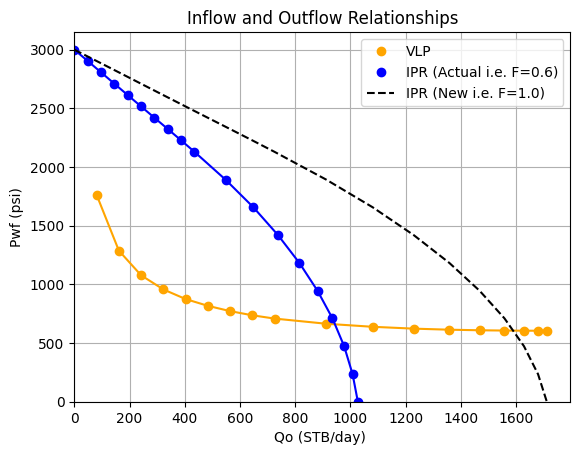

In [19]:
skin(delta_P_skin)